# Figure 1: ZCR Predictability Summary (hdEEG)

Clean summary of out-of-sample predictability for pre-stimulus ZCR predicting post-stimulus ZCR.

Focus: Sessions with genuine generalization (R² ≥ 0) showing reproducible neural dynamics.

## Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 10

# Color scheme
blue_color = plt.cm.Blues(0.6)

## Load Data

In [2]:
# Resolve project root
cwd = Path.cwd().resolve()
if (cwd / 'data').exists():
    project_root = cwd
elif (cwd.parent / 'data').exists():
    project_root = cwd.parent
else:
    raise FileNotFoundError('Could not find project root containing data/.')

metrics_root = project_root / 'data' / 'df_results' / 'hd-eeg_metrics'

# Import additional modules
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr

# Define ZCR metric
ZCR_METRIC = 'zero_crossing_rate'

# Load raw 9MOIs data (required for computation)
csv_path_9mois = metrics_root / 'df_9MOIs_hd-eeg.csv'
df_raw = pd.read_csv(csv_path_9mois)

# Filter for ZCR metric only, radius = 100mm
df = df_raw[
    (df_raw['metric_name'] == ZCR_METRIC) & 
    (df_raw['radius_pre'] == 100) & 
    (df_raw['radius_post'] == 100)
].copy()

print(f'Loaded raw data: {len(df_raw)} rows')
print(f'Filtered to ZCR: {len(df)} rows')
print(f'Computing results...')

Loaded raw data: 2962017 rows
Filtered to ZCR: 9957 rows
Computing results...


## Compute ZCR Predictability (CV Analysis)

In [3]:
def compute_ZCR_cv(pre_vals, post_vals, n_splits=2, random_state=42):
    """Compute OOS R², correlation, and RMSE for ZCR predictability."""
    pre_vals = np.asarray(pre_vals).flatten()
    post_vals = np.asarray(post_vals).flatten()
    
    # Remove NaN pairs
    mask = ~(np.isnan(pre_vals) | np.isnan(post_vals))
    pre_vals = pre_vals[mask]
    post_vals = post_vals[mask]
    n_trials = len(pre_vals)
    
    if n_trials < n_splits or n_trials < 3:
        return {'n_trials': n_trials, 'oos_r2': np.nan, 'oos_corr': np.nan, 
                'oos_rmse': np.nan, 'within_r2': np.nan, 'within_corr': np.nan}
    
    # Fit on full data (reference)
    model_full = LinearRegression()
    model_full.fit(pre_vals.reshape(-1, 1), post_vals)
    y_pred_full = model_full.predict(pre_vals.reshape(-1, 1))
    within_r2 = r2_score(post_vals, y_pred_full)
    within_corr, _ = pearsonr(pre_vals, post_vals)
    
    # K-fold CV
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    r2_scores, corr_scores, rmse_scores = [], [], []
    
    for train_idx, test_idx in kf.split(pre_vals):
        X_train = pre_vals[train_idx].reshape(-1, 1)
        y_train = post_vals[train_idx]
        X_test = pre_vals[test_idx].reshape(-1, 1)
        y_test = post_vals[test_idx]
        
        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        r2_scores.append(r2_score(y_test, y_pred))
        corr_scores.append(pearsonr(y_test, y_pred)[0])
        rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    
    return {
        'n_trials': n_trials,
        'within_r2': within_r2,
        'within_corr': within_corr,
        'oos_r2': np.mean(r2_scores),
        'oos_corr': np.mean(corr_scores),
        'oos_rmse': np.mean(rmse_scores),
    }

# Compute ZCR predictability for all sessions
results = []
for (sub, run), session_df in df.groupby(['sub', 'run_is']):
    pivot = session_df.pivot_table(
        index='trial_id',
        columns='metric_name',
        values=['metric_value_pre', 'metric_value_post'],
        aggfunc='mean'
    )
    
    pre_key = ('metric_value_pre', ZCR_METRIC)
    post_key = ('metric_value_post', ZCR_METRIC)
    
    if pre_key not in pivot.columns or post_key not in pivot.columns:
        continue
    
    metrics = compute_ZCR_cv(pivot[pre_key].values, pivot[post_key].values)
    results.append({'sub': sub, 'run_is': run, **metrics})

df_ZCR = pd.DataFrame(results)
print(f'✓ Computed ZCR predictability for {len(df_ZCR)} sessions')

✓ Computed ZCR predictability for 318 sessions


## Permutation Test: Significance Against Null

In [4]:
# Run permutation test for each session
perm_results = []
n_perm = 100
print(f'Running permutation test ({n_perm} permutations per session)...')

for idx, row in df_ZCR.iterrows():
    sub = row['sub']
    run = row['run_is']
    observed_oos_r2 = row['oos_r2']
    n_trials = row['n_trials']
    
    if np.isnan(observed_oos_r2) or n_trials < 4:
        continue
    
    # Get data for this session
    session_df = df[(df['sub'] == sub) & (df['run_is'] == run)]
    pivot = session_df.pivot_table(
        index='trial_id',
        columns='metric_name',
        values=['metric_value_pre', 'metric_value_post'],
        aggfunc='mean'
    )
    
    pre_key = ('metric_value_pre', ZCR_METRIC)
    post_key = ('metric_value_post', ZCR_METRIC)
    
    pre_vals = pivot[pre_key].values
    post_vals = pivot[post_key].values
    
    mask = ~(np.isnan(pre_vals) | np.isnan(post_vals))
    pre_vals_clean = pre_vals[mask]
    post_vals_clean = post_vals[mask]
    
    # Run permutations
    permuted_r2 = []
    for perm_idx in range(n_perm):
        np.random.seed(42 + perm_idx)
        shuffled_pre = np.random.permutation(pre_vals_clean)
        
        kf = KFold(n_splits=2, shuffle=True, random_state=42 + perm_idx)
        perm_r2_fold = []
        
        for train_idx, test_idx in kf.split(shuffled_pre):
            X_train = shuffled_pre[train_idx].reshape(-1, 1)
            X_test = shuffled_pre[test_idx].reshape(-1, 1)
            y_train = post_vals_clean[train_idx]
            y_test = post_vals_clean[test_idx]
            
            model = LinearRegression()
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            perm_r2_fold.append(r2_score(y_test, y_pred))
        
        permuted_r2.append(np.mean(perm_r2_fold))
    
    permuted_r2 = np.array(permuted_r2)
    n_greater = (permuted_r2 >= observed_oos_r2).sum()
    p_value = n_greater / n_perm
    
    perm_results.append({
        'sub': sub,
        'run_is': run,
        'observed_oos_r2': observed_oos_r2,
        'null_median_r2': np.median(permuted_r2),
        'p_value': p_value,
        'is_significant': p_value < 0.05,
    })

df_perm = pd.DataFrame(perm_results)
print(f'✓ Permutation test complete for {len(df_perm)} sessions')

Running permutation test (100 permutations per session)...
✓ Permutation test complete for 318 sessions


## Filter: R² ≥ 0 Only

In [5]:
# Filter for positive OOS R² (genuine generalization)
df_good = df_ZCR[df_ZCR['oos_r2'] >= 0].copy()

# Merge with significance information
df_good = df_good.reset_index(drop=True)
df_perm_aligned = df_perm.reset_index(drop=True)

# Create significance mask aligned with df_good
mask_positive = df_ZCR['oos_r2'] >= 0
sig_mask = df_perm_aligned.iloc[df_ZCR[mask_positive].index]['is_significant'].values

df_good['is_significant'] = sig_mask

n_total = len(df_ZCR)
n_good = len(df_good)
pct_good = n_good / n_total * 100
n_sig = df_good['is_significant'].sum()

print(f'\nFiltered Results:')
print(f'  Sessions with R² ≥ 0: {n_good}/{n_total} ({pct_good:.1f}%)')
print(f'  Significant cases (p<0.05): {n_sig}/{n_good} ({n_sig/n_good*100:.1f}%)')


Filtered Results:
  Sessions with R² ≥ 0: 69/318 (21.7%)
  Significant cases (p<0.05): 51/69 (73.9%)


## Summary Statistics (R² ≥ 0 cases)

In [6]:
print('\n' + '='*80)
print('ZCR PREDICTABILITY: POSITIVE OOS R² CASES ONLY (hdEEG)')
print('='*80)

print(f'\nOut-of-Sample R²:')
print(f'  Mean:   {df_good["oos_r2"].mean():.3f}')
print(f'  Median: {df_good["oos_r2"].median():.3f}')
print(f'  Max:    {df_good["oos_r2"].max():.3f}')
print(f'  Std:    {df_good["oos_r2"].std():.3f}')

print(f'\nOut-of-Sample Correlation:')
print(f'  Mean:   {df_good["oos_corr"].mean():.3f}')
print(f'  Median: {df_good["oos_corr"].median():.3f}')
print(f'  Max:    {df_good["oos_corr"].max():.3f}')
print(f'  Std:    {df_good["oos_corr"].std():.3f}')

print(f'\nSample Sizes:')
print(f'  Mean trials: {df_good["n_trials"].mean():.0f}')
print(f'  Median trials: {df_good["n_trials"].median():.0f}')


ZCR PREDICTABILITY: POSITIVE OOS R² CASES ONLY (hdEEG)

Out-of-Sample R²:
  Mean:   0.124
  Median: 0.078
  Max:    0.579
  Std:    0.129

Out-of-Sample Correlation:
  Mean:   0.422
  Median: 0.424
  Max:    0.792
  Std:    0.150

Sample Sizes:
  Mean trials: 33
  Median trials: 35


## Figure 1: Distribution of Performance Metrics

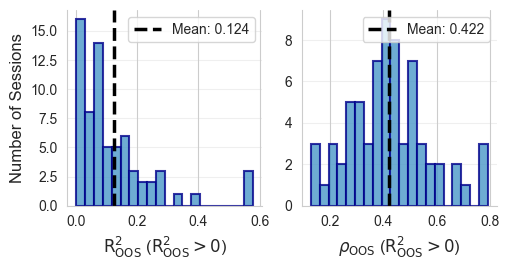

✓ Saved: Figure_1_ZCR_predictability_hdEEG.png


In [7]:
# Apply Figure_1_C styling
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

fig, axes = plt.subplots(1, 2, figsize=(5.2, 2.8))

# Panel A: OOS R² Distribution
ax = axes[0]
ax.hist(df_good['oos_r2'], bins=20, color=blue_color, edgecolor='darkblue', linewidth=1.5, alpha=0.8)
ax.axvline(df_good['oos_r2'].mean(), color='k', linestyle='--', linewidth=2.5, label=f'Mean: {df_good["oos_r2"].mean():.3f}')
ax.set_xlabel('$\\mathrm{R}^2_{\mathrm{OOS}}$ ($\\mathrm{R}^2_{\mathrm{OOS}}>0$)', fontsize=12)
ax.set_ylabel('Number of Sessions', fontsize=12)
#ax.set_title('OOS R² Distribution', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Panel B: OOS Correlation Distribution
ax = axes[1]
ax.hist(df_good['oos_corr'], bins=20, color=blue_color, edgecolor='darkblue', linewidth=1.5, alpha=0.8)
ax.axvline(df_good['oos_corr'].mean(), color='k', linestyle='--', linewidth=2.5, label=f'Mean: {df_good["oos_corr"].mean():.3f}')
ax.set_xlabel('$\\rho_{\mathrm{OOS}}$ ($\\mathrm{R}^2_{\mathrm{OOS}}>0$)', fontsize=12)
#ax.set_ylabel('Number of Sessions', fontsize=12)
#ax.set_title('OOS Correlation Distribution', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../results/figures/Figure_1_ZCR_predictability_hdEEG.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

print('✓ Saved: Figure_1_ZCR_predictability_hdEEG.png')

## Figure 2: Per-Participant Performance

In [8]:
# Per-subject statistics (using good cases only)
subject_stats = df_good.groupby('sub').agg({
    'oos_r2': ['count', 'mean', 'max'],
    'oos_corr': ['mean', 'max'],
    'is_significant': 'sum'
}).round(3)

subject_stats.columns = ['n_sessions', 'mean_r2', 'max_r2', 'mean_corr', 'max_corr', 'n_significant']
subject_stats = subject_stats.sort_values('mean_r2', ascending=False)

print(f'\nPer-Subject Statistics (R² ≥ 0 cases only):')
print(subject_stats.head(15).to_string())


Per-Subject Statistics (R² ≥ 0 cases only):
        n_sessions  mean_r2  max_r2  mean_corr  max_corr  n_significant
sub                                                                    
sub-06           3    0.512   0.579      0.753     0.792              3
sub-16           3    0.286   0.579      0.531     0.788              2
sub-03           4    0.150   0.265      0.451     0.519              3
sub-29           3    0.147   0.325      0.455     0.562              3
sub-12           7    0.143   0.237      0.418     0.524              6
sub-35           8    0.143   0.279      0.520     0.701              7
sub-02           5    0.128   0.239      0.404     0.570              4
sub-26           2    0.125   0.171      0.390     0.468              2
sub-24           3    0.120   0.174      0.400     0.455              3
sub-11           1    0.114   0.114      0.460     0.460              1
sub-36           2    0.097   0.124      0.328     0.371              2
sub-10           2 

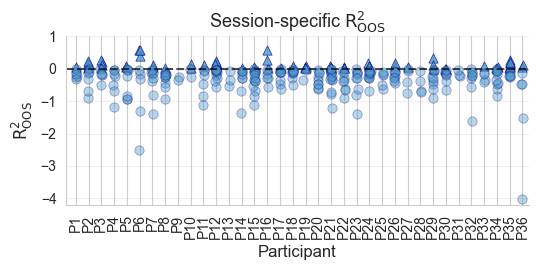

✓ Saved: Figure_1_ZCR_predictability_persub_hdEEG.png


In [9]:
# Apply Figure_1_C styling
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

# Get all unique subjects and sort them numerically
all_subjects = sorted(df_ZCR['sub'].unique(), key=lambda x: int(x.split('-')[1]))

# Create mapping from subject names to P1, P2, etc (P1 = sub-01, P2 = sub-02, etc)
subject_to_p = {sub: f'P{int(sub.split("-")[1])}' for sub in all_subjects}
p_labels = [subject_to_p[sub] for sub in all_subjects]

# Panel A: Individual session R² values per subject (ALL sessions including negative)
plt.figure(figsize=(5.5, 2.8))
x_pos = 0
for subject in all_subjects:
    subject_data = df_ZCR[df_ZCR['sub'] == subject]
    r2_values = subject_data['oos_r2'].values
    x_positions = np.random.normal(x_pos, 0.04, size=len(r2_values))
    
    # Separate positive and non-positive R² sessions
    mask_positive = r2_values >= 0
    
    # Plot R² > 0 with up triangles
    if mask_positive.sum() > 0:
        plt.scatter(x_positions[mask_positive], r2_values[mask_positive], s=45, alpha=0.8, 
                   color=blue_color, edgecolors='darkblue', linewidth=0.5, marker='^')
    
    # Plot R² <= 0 with circles
    if (~mask_positive).sum() > 0:
        plt.scatter(x_positions[~mask_positive], r2_values[~mask_positive], s=45, alpha=0.4, 
                   color=blue_color, edgecolors='darkblue', linewidth=0.5, marker='o')
    
    x_pos += 1

plt.axhline(y=0, color='k', linestyle='--', linewidth=1.5, alpha=0.7)
plt.xticks(ticks=np.arange(len(all_subjects)), labels=p_labels, rotation=90)
plt.ylabel('$\\mathrm{R}^2_{\mathrm{OOS}}$', fontsize=12)
plt.xlabel('Participant', fontsize=12)
plt.title('Session-specific $\\mathrm{R}^2_{\mathrm{OOS}}$', fontsize=13)
plt.grid(True, alpha=0.3, axis='y')
plt.xlim(-.75, len(all_subjects)-.5)
plt.ylim(-4.2, 1)

plt.tight_layout()
plt.savefig('../results/figures/Figure_1_ZCR_predictability_persub_hdEEG.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

print('✓ Saved: Figure_1_ZCR_predictability_persub_hdEEG.png')

## Summary Table for Publication

In [10]:
print('\n' + '='*100)
print('PUBLICATION SUMMARY: ZCR PREDICTABILITY (hdEEG)')
print('='*100)

print(f'\nOverall Results (R² ≥ 0 cases):')  
print(f'  Total sessions analyzed: {n_total}')
print(f'  Sessions with positive generalization (R² ≥ 0): {n_good} ({pct_good:.1f}%)')
print(f'  Sessions with significant predictability (p<0.05): {n_sig} ({n_sig/n_total*100:.1f}% of total)')

print(f'\nPerformance Metrics (R² ≥ 0 cases):')  
print(f'  Out-of-Sample R²:')
print(f'    Mean: {df_good["oos_r2"].mean():.3f} ± {df_good["oos_r2"].std():.3f}')
print(f'    Range: [{df_good["oos_r2"].min():.3f}, {df_good["oos_r2"].max():.3f}]')

print(f'\n  Out-of-Sample Correlation:')
print(f'    Mean: {df_good["oos_corr"].mean():.3f} ± {df_good["oos_corr"].std():.3f}')
print(f'    Range: [{df_good["oos_corr"].min():.3f}, {df_good["oos_corr"].max():.3f}]')

print(f'\nParticipant Coverage:')
print(f'  Number of subjects: {df_good["sub"].nunique()}')
print(f'  Mean sessions per subject: {df_good.groupby("sub").size().mean():.1f}')
print(f'  Min/Max sessions per subject: {df_good.groupby("sub").size().min()}/{df_good.groupby("sub").size().max()}')


PUBLICATION SUMMARY: ZCR PREDICTABILITY (hdEEG)

Overall Results (R² ≥ 0 cases):
  Total sessions analyzed: 318
  Sessions with positive generalization (R² ≥ 0): 69 (21.7%)
  Sessions with significant predictability (p<0.05): 51 (16.0% of total)

Performance Metrics (R² ≥ 0 cases):
  Out-of-Sample R²:
    Mean: 0.124 ± 0.129
    Range: [0.001, 0.579]

  Out-of-Sample Correlation:
    Mean: 0.422 ± 0.150
    Range: [0.128, 0.792]

Participant Coverage:
  Number of subjects: 27
  Mean sessions per subject: 2.6
  Min/Max sessions per subject: 1/8


## Subject-Level Results Table

In [11]:
# Export results table
output_table = subject_stats.copy()
output_table['pct_significant'] = (output_table['n_significant'] / output_table['n_sessions'] * 100).round(1)
output_table = output_table[['n_sessions', 'mean_r2', 'max_r2', 'mean_corr', 'max_corr', 'n_significant', 'pct_significant']]

print('\nSubject-Level Results (sorted by mean R²):')
print(output_table.to_string())

# Save to CSV
output_csv = Path('Figure_1_ZCR_subject_summary_hdEEG.csv')
output_table.to_csv(output_csv)
print(f'\n✓ Saved: {output_csv}')


Subject-Level Results (sorted by mean R²):
        n_sessions  mean_r2  max_r2  mean_corr  max_corr  n_significant  pct_significant
sub                                                                                     
sub-06           3    0.512   0.579      0.753     0.792              3            100.0
sub-16           3    0.286   0.579      0.531     0.788              2             66.7
sub-03           4    0.150   0.265      0.451     0.519              3             75.0
sub-29           3    0.147   0.325      0.455     0.562              3            100.0
sub-12           7    0.143   0.237      0.418     0.524              6             85.7
sub-35           8    0.143   0.279      0.520     0.701              7             87.5
sub-02           5    0.128   0.239      0.404     0.570              4             80.0
sub-26           2    0.125   0.171      0.390     0.468              2            100.0
sub-24           3    0.120   0.174      0.400     0.455          